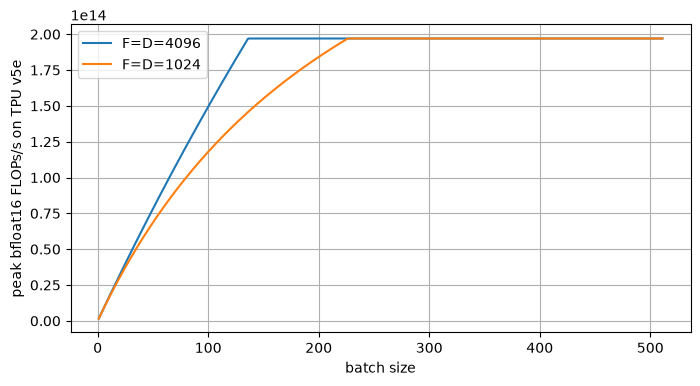

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def roofline(B, D, F):
    flops = 2 * B * D * F
    t_math = flops / 1.97e14
    t_comm = (2 * B * D + D * F + 2 * B * F) / 8.2e11
    time = np.maximum(t_math, t_comm)
    return flops / time

bs = np.arange(1, 512)
roofline_big = roofline(bs, 4096, 4096)
roofline_small = roofline(bs, 1024, 1024)

plt.figure(figsize=(8, 4))
plt.plot(bs, roofline_big, label='F=D=4096')
plt.plot(bs, roofline_small, label='F=D=1024')
plt.legend()
plt.xlabel('batch size')
plt.ylabel('peak bfloat16 FLOPs/s on TPU v5e')
plt.grid()
